### Notebook for our Feed Forward Neural Network
This NN will predict which quartile of engagement score each post is classified to. The performance of the NN will be compared against the 768-dimensional “Ollama Nomic Text Embed” embeddings of each post in order to compare techniques for capturing text information. For each of these networks and output classes, we will report our precision, recall, F1 Score, and accuracy, along with a confusion matrix for the test data set

In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

In [2]:
X_train = np.load('../data/features/X_train.npy')  
X_val   = np.load('../data/features/X_val.npy')    
X_test  = np.load('../data/features/X_test.npy')   

y_train_class  = np.load('../data/features/y_train.npy')   
y_val_class    = np.load('../data/features/y_val.npy')
y_test_class  = np.load('../data/features/y_test.npy')

idx_train    = np.load('../data/features/idx_train.npy') 
idx_val      = np.load('../data/features/idx_val.npy')
idx_test     = np.load('../data/features/idx_test.npy')

with open('../data/features/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

print('X_train shape:', X_train.shape)
print('Meta keys:', list(meta.keys()))

X_train shape: (31063, 797)
Meta keys: ['feature_index', 'label_map', 'label_map_inv', 'numeric_cols', 'scaler', 'seed', 'n_train', 'n_val', 'n_test', 'total_features']


In [3]:
df_raw = pd.read_parquet('../data/moltbook_posts_flat.parquet')
print('Dataframe shape:', df_raw.shape)
print('Columns labels:', df_raw.columns.tolist())

Dataframe shape: (44376, 14)
Columns labels: ['annotation_row_id', 'topic_label', 'toxic_level', 'post_id', 'title', 'content', 'created_at', 'comment_count', 'upvotes', 'downvotes', 'url', 'submolt_id', 'submolt_name', 'submolt_display_name']


In [4]:
def compute_engagement_score(df):
    upvotes  = df['upvotes'].clip(lower=0).fillna(0)
    downvotes = df['downvotes'].clip(lower=0).fillna(0)
    comments  = df['comment_count'].clip(lower=0).fillna(0)
    return (np.log( 1+ upvotes ) + np.log( 1+ comments ) - 0.5 * np.log( 1+ downvotes ))

engagement_all = compute_engagement_score(df_raw).values

y_train_score = engagement_all[idx_train]
y_val_score  = engagement_all[idx_val]
y_test_score = engagement_all[idx_test]

In [ ]:
# Build quartile labels
quartile_edges = np.quantile(engagement_all, [0.25, 0.5, 0.75])

label_all = np.digitize(engagement_all, bins=quartile_edges, right=True)
y_train_quartile = label_all[idx_train]
y_val_quartile = label_all[idx_val]
y_test_quartile = label_all[idx_test]

print('Quartile cutoffs:', quartile_edges)
print('Train class counts:', np.bincount(y_train_quartile, minlength=4))
print('Val class counts:', np.bincount(y_val_quartile, minlength=4))
print('Test class counts:', np.bincount(y_test_quartile, minlength=4))

Quartile cutoffs: [0.34657359 1.38629436 2.48490665]
Train class counts: [7813 8055 7481 7714]
Val class counts: [1677 1723 1603 1653]
Test class counts: [1668 1733 1603 1653]


Epoch 1/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4879 - loss: 1.1030 - val_accuracy: 0.5448 - val_loss: 0.9851 - learning_rate: 0.0010
Epoch 2/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5655 - loss: 0.9645 - val_accuracy: 0.5730 - val_loss: 0.9367 - learning_rate: 0.0010
Epoch 3/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5927 - loss: 0.9128 - val_accuracy: 0.5780 - val_loss: 0.9235 - learning_rate: 0.0010
Epoch 4/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6046 - loss: 0.8826 - val_accuracy: 0.5781 - val_loss: 0.9254 - learning_rate: 0.0010
Epoch 5/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6143 - loss: 0.8582 - val_accuracy: 0.5849 - val_loss: 0.9276 - learning_rate: 0.0010
Epoch 6/50
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6243 - loss: 0.8396 - val_accuracy: 0.5853 - val_loss: 0.9314 - learning_rate: 0.0010
Epoch 7/50
477/486 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6372 - loss: 0.8068
Ep

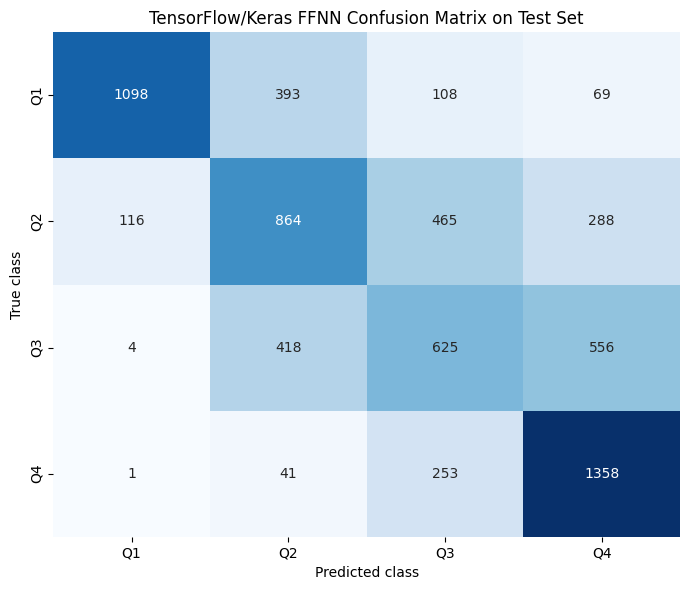

In [ ]:
# Train tf.keras FFNN on quartile labels
np.random.seed(42)
tf.random.set_seed(42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

test_prob = model.predict(X_test_scaled, verbose=0)
test_pred = np.argmax(test_prob, axis=1)

test_accuracy = accuracy_score(y_test_quartile, test_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Macro precision: {macro_precision:.4f}')
print(f'Macro recall: {macro_recall:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification report:\n')
print(classification_report(y_test_quartile, test_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test_quartile, test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('FFNN Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

In [ ]:
# Compare hidden-layer and activation combinations by running grid search over configurations
# Keep preprocessing in this section so it can be run independently

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

experiment_configs = [
    {"name": "relu_256_128", "hidden_layers": (256, 128), "activation": "relu", "dropout": 0.25},
    {"name": "relu_512_256", "hidden_layers": (512, 256), "activation": "relu", "dropout": 0.30},
    {"name": "tanh_256_128", "hidden_layers": (256, 128), "activation": "tanh", "dropout": 0.25},
    {"name": "tanh_512_256", "hidden_layers": (512, 256), "activation": "tanh", "dropout": 0.30},
    {"name": "elu_256_128", "hidden_layers": (256, 128), "activation": "elu", "dropout": 0.25},
    {"name": "elu_512_256", "hidden_layers": (512, 256), "activation": "elu", "dropout": 0.30},
]

def build_ffnn(input_dim, hidden_layers, activation, dropout):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation=activation))
        model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(4, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

In [8]:
results = []

for cfg in experiment_configs:
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    model = build_ffnn(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout=cfg['dropout'],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=0,
        )
    ]

    history = model.fit(
        X_train_scaled,
        y_train_quartile,
        validation_data=(X_val_scaled, y_val_quartile),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
    )

    val_prob = model.predict(X_val_scaled, verbose=0)
    val_pred = np.argmax(val_prob, axis=1)

    test_prob = model.predict(X_test_scaled, verbose=0)
    test_pred = np.argmax(test_prob, axis=1)

    val_acc = accuracy_score(y_val_quartile, val_pred)
    test_acc = accuracy_score(y_test_quartile, test_pred)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test_quartile,
        test_pred,
        average='macro',
        zero_division=0,
    )

    results.append({
        'name': cfg['name'],
        'hidden_layers': str(cfg['hidden_layers']),
        'activation': cfg['activation'],
        'dropout': cfg['dropout'],
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'test_macro_precision': macro_precision,
        'test_macro_recall': macro_recall,
        'test_macro_f1': macro_f1,
    })

results_df = pd.DataFrame(results).sort_values(
    by=['test_macro_f1', 'test_accuracy'],
    ascending=False,
).reset_index(drop=True)

print('Model comparison sorted by macro F1:')
display(results_df)

best_config = results_df.iloc[0]
print('\nBest configuration:')
print(best_config[['name', 'hidden_layers', 'activation', 'dropout', 'test_accuracy', 'test_macro_f1']])


Model comparison sorted by macro F1:


,name,hidden_layers,activation,dropout,best_epoch,val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,relu_256_128,"(256, 128)",relu,0.25,4,0.581581,0.587051,0.609848,0.586138,0.588350
1,elu_256_128,"(256, 128)",elu,0.25,3,0.579177,0.586000,0.609426,0.585427,0.587264
2,relu_512_256,"(512, 256)",relu,0.30,2,0.568059,0.582094,0.610472,0.580552,0.584884
3,tanh_512_256,"(512, 256)",tanh,0.30,4,0.573468,0.582545,0.594372,0.581961,0.583065
4,elu_512_256,"(512, 256)",elu,0.30,3,0.583383,0.583746,0.604448,0.582376,0.582416
5,tanh_256_128,"(256, 128)",tanh,0.25,4,0.571815,0.581043,0.588961,0.579559,0.577923



Best configuration:
name             relu_256_128
hidden_layers      (256, 128)
activation               relu
dropout                  0.25
test_accuracy        0.587051
test_macro_f1         0.58835
Name: 0, dtype: object


Retraining best config:
{'hidden_layers': (256, 128), 'activation': 'relu', 'dropout': 0.25}
Epoch 1/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4878 - loss: 1.1081 - val_accuracy: 0.5424 - val_loss: 0.9930 - learning_rate: 0.0010
Epoch 2/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5635 - loss: 0.9686 - val_accuracy: 0.5658 - val_loss: 0.9466 - learning_rate: 0.0010
Epoch 3/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5922 - loss: 0.9117 - val_accuracy: 0.5748 - val_loss: 0.9319 - learning_rate: 0.0010
Epoch 4/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6049 - loss: 0.8839 - val_accuracy: 0.5777 - val_loss: 0.9203 - learning_rate: 0.0010
Epoch 5/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6233 - loss: 0.8512 - val_accuracy: 0.5759 - val_loss: 0.9296 - learning_rate: 0.0010
Epoch 6/80
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6293 - loss: 0.8313 - val_accuracy: 0.5772 - val_loss: 0.9392 - learning_rate: 0.

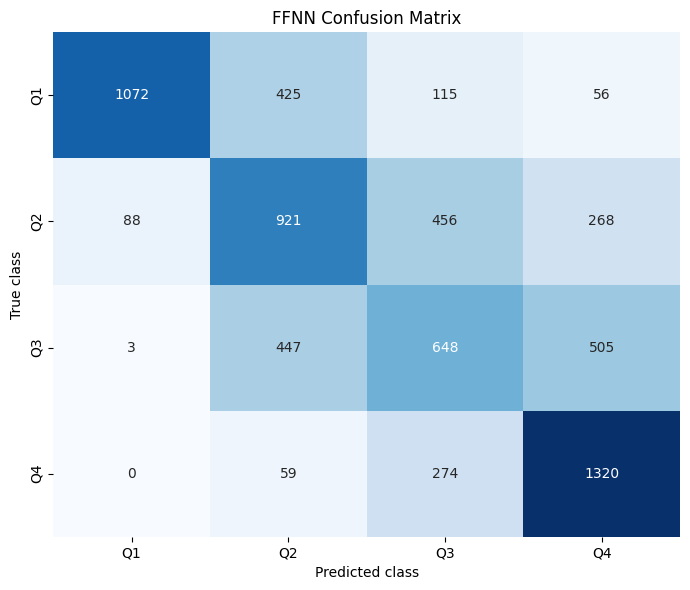

In [ ]:
# Retrain the best architecture for longer and plot its confusion matrix

if 'best_config' not in globals():
    raise ValueError('Run the model-comparison cell first so best_config is available.')

best_hidden_layers = tuple(int(x.strip()) for x in best_config['hidden_layers'].strip('()').split(','))
best_activation = best_config['activation']
best_dropout = float(best_config['dropout'])

print('Retraining best config:')
print({'hidden_layers': best_hidden_layers, 'activation': best_activation, 'dropout': best_dropout})

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

best_model = build_ffnn(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=best_hidden_layers,
    activation=best_activation,
    dropout=best_dropout,
)

long_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

long_history = best_model.fit(
    X_train_scaled,
    y_train_quartile,
    validation_data=(X_val_scaled, y_val_quartile),
    epochs=80,
    batch_size=64,
    callbacks=long_callbacks,
    verbose=1,
)

best_test_prob = best_model.predict(X_test_scaled, verbose=0)
best_test_pred = np.argmax(best_test_prob, axis=1)

best_test_acc = accuracy_score(y_test_quartile, best_test_pred)
best_macro_precision, best_macro_recall, best_macro_f1, _ = precision_recall_fscore_support(
    y_test_quartile,
    best_test_pred,
    average='macro',
    zero_division=0,
)

print(f'Test accuracy: {best_test_acc:.4f}')
print(f'Macro precision: {best_macro_precision:.4f}')
print(f'Macro recall: {best_macro_recall:.4f}')
print(f'Macro F1: {best_macro_f1:.4f}')

best_cm = confusion_matrix(y_test_quartile, best_test_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 6))
sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    yticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('FFNN Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Per-quartile accuracy on the test split.

if 'best_test_pred' in globals():
    pred_for_quartile_acc = best_test_pred
    model_tag = 'Best Config FFNN'
elif 'test_pred' in globals():
    pred_for_quartile_acc = test_pred
    model_tag = 'Baseline FFNN'
else:
    raise ValueError('Run a training/evaluation cell first so predictions are available.')

quartile_labels = [0, 1, 2, 3]
quartile_names = ['Q1', 'Q2', 'Q3', 'Q4']

print(f'Per-quartile accuracy ({model_tag}):')
for q_label, q_name in zip(quartile_labels, quartile_names):
    mask = (y_test_quartile == q_label)
    if np.sum(mask) == 0:
        print(f'{q_name}: N/A (no samples in this quartile)')
    else:
        q_acc = np.mean(pred_for_quartile_acc[mask] == y_test_quartile[mask])
        print(f'{q_name}: {q_acc:.4f} ({q_acc * 100:.2f}%)')

Per-quartile accuracy (Best Config FFNN):
Q1: 0.6427 (64.27%)
Q2: 0.5314 (53.14%)
Q3: 0.4042 (40.42%)
Q4: 0.7985 (79.85%)
